# Evaluate pipeline

In [18]:
# Custom imports
from src.segmentation_pipeline import convex_segmentation
from src.model_run import start_prediction_machine, detectron2_instances
from src.classic_instances import instance_regions
from src.fusion import fusion_of_masks
from src.classifier import reclassify_instances
from src.coco_json_functions import export_to_coco, labelme_to_coco
from src.model_run import CLASSES

# Required imports for classifiers
from sklearn.base import TransformerMixin, BaseEstimator
class SelectColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, xs, ys, **params):
        return self
    def transform(self, xs):
        return xs[self.columns]

# Generate output coco files

In [19]:
def instance_segmentation_pipeline(img_path, model_path, bmp_cls, bg_cls):
    # function returns the mask for the root and the mask for the hairs as seperate variables
    root, hairs = convex_segmentation(img_path, save=False, verbose = False)

    # get a list of each unique instance mask of root hairs
    classic_masks = instance_regions(hairs, root)

    # predictor is the segmentaion model as a variable
    predictor = start_prediction_machine(path_to_model=model_path, instance_based=True)

    # Instances is a list of all found instances in the image, including bounding box, mask, label, and label id
    model_instances = detectron2_instances(predictor, img_path)

    instances = fusion_of_masks(classic_masks, model_instances)
    final_instances = reclassify_instances(instances, root, img_path, bmp_cls, bg_cls)

    export_to_coco(final_instances, img_path, CLASSES, epsilon=0.5)

    return final_instances

In [20]:
# Image
img_path = "/home/mellanie/Desktop/pipeline_code/20250129_N4_Plate6_DAG6_1000_L/000018.tif"
img_annotations = "/home/mellanie/Desktop/pipeline_code/20250129_N4_Plate6_DAG6_1000_L/labelme_annotations/000018.json"

# Model to use
model_path = "/home/mellanie/Desktop/container/model/segmentation_models/instance_no_root.pth"

# Classifiers
bmp_cls = "/home/mellanie/Desktop/container/model/classifiers/bumps_embedded_classifier.pkl"
bg_cls = "/home/mellanie/Desktop/container/model/classifiers/bg_regular_classifier.pkl"

In [21]:
%%capture
# generate a coco file using the pipeline we have built.
final_instances = instance_segmentation_pipeline(img_path, model_path, bmp_cls, bg_cls)

# generate a coco file from the label me annotations
labelme_to_coco(img_annotations, img_path, CLASSES, image_id=0)

# Evaluate files

In [22]:
# import json
# import pycocotools

# # load in generated coco files
# predicted = "outputs/segmentation_outputs_coco.json"
# truth = "outputs/ground_truth_coco.json"

# json.load

# prepare method to evaluate and compare the two methods

In [23]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils


def load_coco(path):
    with open(path, "r") as f:
        return json.load(f)


def polygon_to_mask(segmentation, height, width):
    """Convert one annotation's polygon segmentation into a binary mask."""
    rles = mask_utils.frPyObjects(segmentation, height, width)
    rle = mask_utils.merge(rles)
    return mask_utils.decode(rle)


def build_flattened_mask(coco_data, image_id=0):
    """
    MANDATORY PARAMETERS:
        coco_data -- loaded COCO dict
        image_id  -- which image's annotations to flatten

    OUTPUT:
        single 2D binary mask (union of every annotation for that image)
    """
    image_info = next(img for img in coco_data["images"] if img["id"] == image_id)
    height, width = image_info["height"], image_info["width"]

    flattened = np.zeros((height, width), dtype=np.uint8)

    anns = [a for a in coco_data["annotations"] if a["image_id"] == image_id]

    for ann in anns:
        inst_mask = polygon_to_mask(ann["segmentation"], height, width)
        flattened = np.logical_or(flattened, inst_mask).astype(np.uint8)

    return flattened

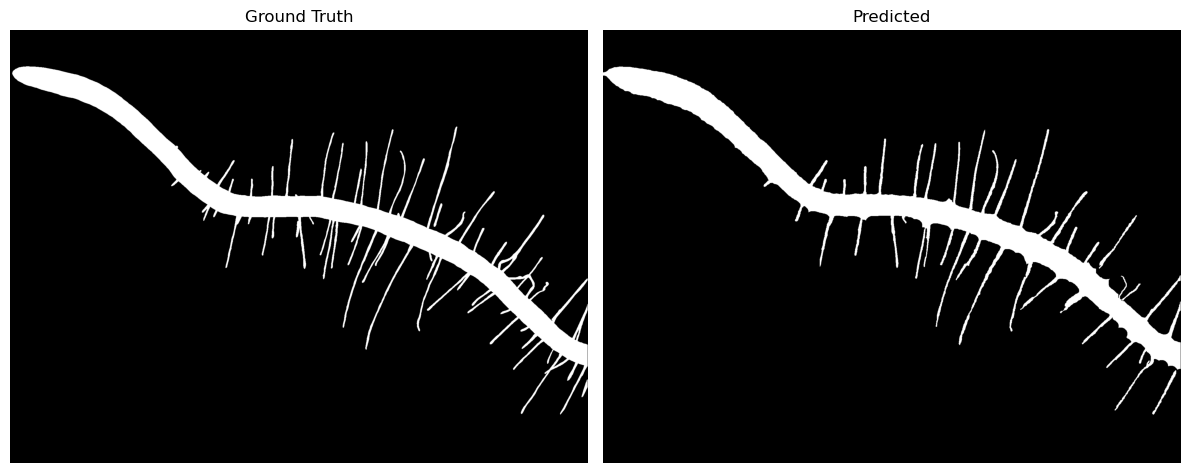

In [ ]:
truth = "outputs/ground_truth_coco.json"
predicted = "outputs/segmentation_outputs_coco.json"

true_coco_data = load_coco(truth)
predicted_coco_data = load_coco(predicted)

true_flat_mask = build_flattened_mask(true_coco_data)
predicted_flat_mask = build_flattened_mask(predicted_coco_data)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(true_flat_mask, cmap="gray")
axes[0].axis("off")
axes[0].set_title("Ground Truth")

axes[1].imshow(predicted_flat_mask, cmap="gray")
axes[1].axis("off")
axes[1].set_title("Predicted")

plt.tight_layout()
plt.show()

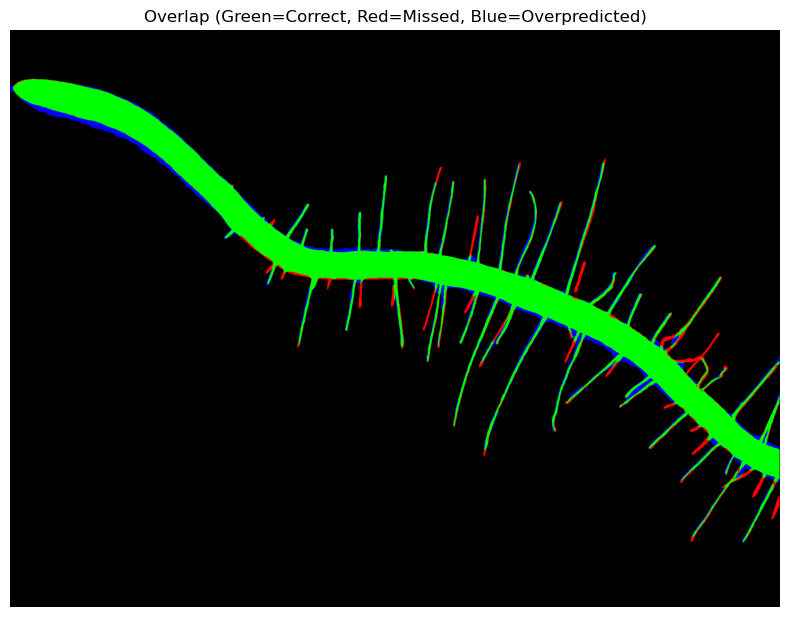

In [ ]:

true_bool = true_flat_mask.astype(bool)
pred_bool = predicted_flat_mask.astype(bool)

correct_overlap = np.logical_and(true_bool, pred_bool)      # both agree: green
false_positive = np.logical_and(pred_bool, ~true_bool)      # predicted only: red
false_negative = np.logical_and(true_bool, ~pred_bool)      # missed by pred: red

# build an RGB image
height, width = true_flat_mask.shape
overlay = np.zeros((height, width, 3), dtype=np.uint8)

overlay[correct_overlap] = [0, 255, 0]      # green
overlay[false_positive] = [0, 0, 255]       # red
overlay[false_negative] = [255, 0, 0]       # red 

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title("Overlap (Green=Correct, Red=Missed, Blue=Overpredicted)")
plt.tight_layout()
plt.show()

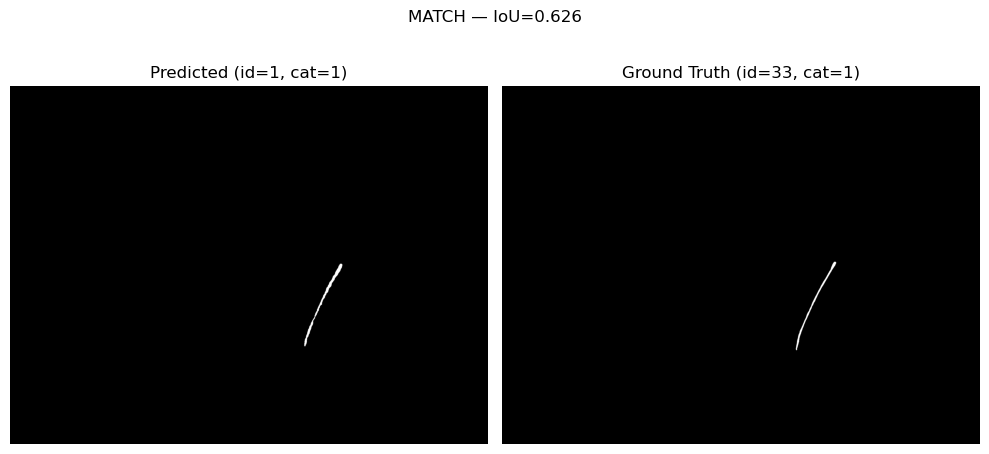

[NO MATCH] pred_id=1  iou=0.626


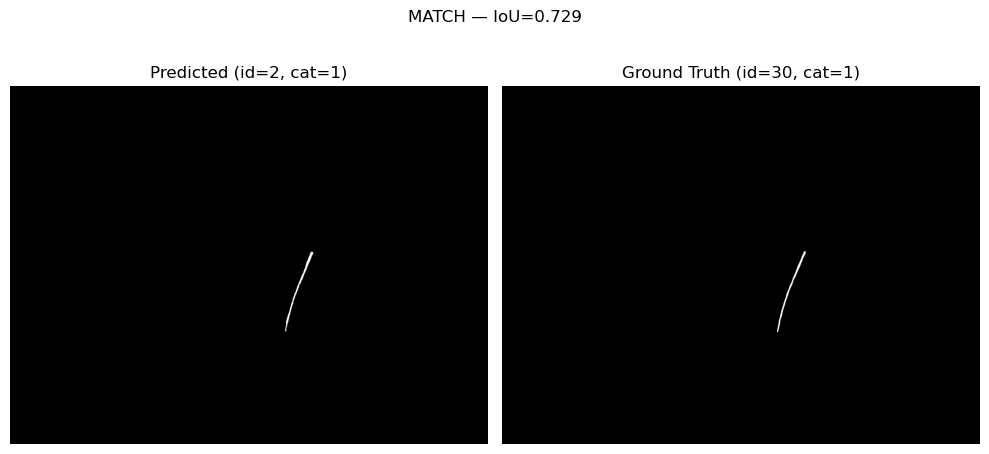

[NO MATCH] pred_id=2  iou=0.729


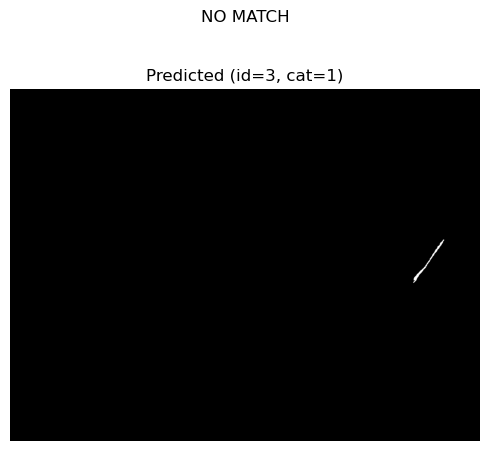

[NO MATCH] pred_id=3  iou=0.000


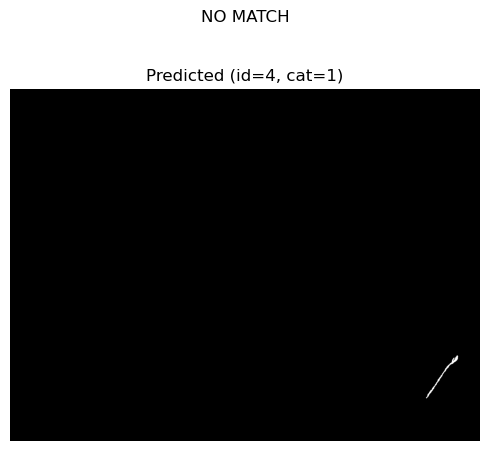

[NO MATCH] pred_id=4  iou=0.000


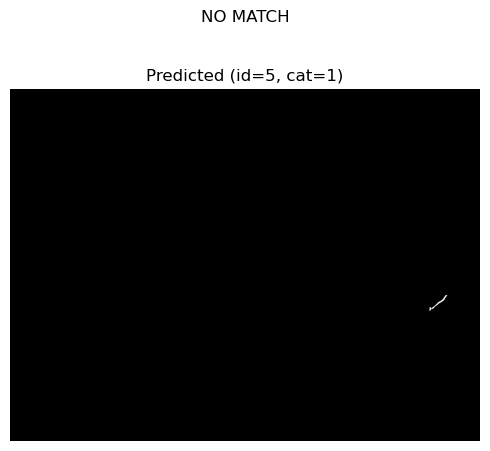

[NO MATCH] pred_id=5  iou=0.000


In [ ]:
from scipy.optimize import linear_sum_assignment
from pycocotools import mask as mask_utils



def compute_iou(mask_a, mask_b):
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return intersection / union if union > 0 else 0.0


def match_predicted_to_ground_truth(pred_anns, gt_anns, height, width,
                                     iou_threshold=0.5, limit=None):
    """
    Match predicted instances to ground truth instances by area overlap
    (IoU) only. category_id is NOT used to constrain matching -- it's only
    used afterward to check if the matched pair agrees on class.

    MANDATORY PARAMETERS:
        pred_anns -- list of predicted COCO annotation dicts (single image)
        gt_anns   -- list of ground truth COCO annotation dicts (single image)
        height, width -- image dimensions for polygon decoding

    OPTIONAL PARAMETERS:
        iou_threshold -- minimum IoU to count as a valid match (default 0.5)
        limit -- if set, only process the first N predicted instances
                 (excluding root, category_id == 0)

    OUTPUT:
        list of match dicts, one per predicted instance considered:
        {
            "pred_id": ...,
            "pred_category": ...,
            "matched_gt_id": ... or None,
            "matched_gt_category": ... or None,
            "iou": ...,
            "category_match": True/False/None,
        }
    """
    # Tristan note: filter out root (category_id == 0) from BOTH sides --
    # root is handled separately and shouldn't compete for matches or
    # inflate/deflate the instance-matching stats
    pred_filtered = [a for a in pred_anns if a["category_id"] != 0]
    gt_filtered = [a for a in gt_anns if a["category_id"] != 0]

    if limit is not None:
        pred_filtered = pred_filtered[:limit]

    if len(pred_filtered) == 0 or len(gt_filtered) == 0:
        return [
            {
                "pred_id": a["id"],
                "pred_category": a["category_id"],
                "matched_gt_id": None,
                "matched_gt_category": None,
                "iou": 0.0,
                "category_match": None,
            }
            for a in pred_filtered
        ]

    # decode masks once, up front, so we're not re-decoding polygons
    # inside the IoU double loop
    pred_masks = [polygon_to_mask(a["segmentation"], height, width) for a in pred_filtered]
    gt_masks = [polygon_to_mask(a["segmentation"], height, width) for a in gt_filtered]

    # build IoU cost matrix (area-only, category-agnostic)
    n_pred, n_gt = len(pred_masks), len(gt_masks)
    iou_matrix = np.zeros((n_pred, n_gt), dtype=np.float64)

    for i in range(n_pred):
        for j in range(n_gt):
            iou_matrix[i, j] = compute_iou(pred_masks[i], gt_masks[j])

    # Hungarian algorithm -- guarantees a 1-to-1 assignment, so no
    # predicted instance can be paired with more than one ground truth
    # instance and vice versa. This is what enforces "no duplicates."
    cost_matrix = -iou_matrix
    pred_idx, gt_idx = linear_sum_assignment(cost_matrix)

    # map assignment results back onto predicted instances
    assignment = {p_i: g_i for p_i, g_i in zip(pred_idx, gt_idx)}

    results = []
    for i, pred_ann in enumerate(pred_filtered):
        if i in assignment and iou_matrix[i, assignment[i]] >= iou_threshold:
            gt_i = assignment[i]
            gt_ann = gt_filtered[gt_i]
            results.append({
                "pred_id": pred_ann["id"],
                "pred_category": pred_ann["category_id"],
                "matched_gt_id": gt_ann["id"],
                "matched_gt_category": gt_ann["category_id"],
                "iou": float(iou_matrix[i, gt_i]),
                "category_match": pred_ann["category_id"] == gt_ann["category_id"],
            })
        else:
            # no ground truth instance overlapped this prediction enough
            results.append({
                "pred_id": pred_ann["id"],
                "pred_category": pred_ann["category_id"],
                "matched_gt_id": None,
                "matched_gt_category": None,
                "iou": 0.0,
                "category_match": None,
            })

    return results




image_info = next(img for img in true_coco_data["images"])
height, width = image_info["height"], image_info["width"]

pred_anns = [a for a in predicted_coco_data["annotations"]]
gt_anns = [a for a in true_coco_data["annotations"]]

matches = match_predicted_to_ground_truth(pred_anns, gt_anns, height, width, iou_threshold=0.5, limit=5)

for m in matches:
 
    pred_by_id = {a["id"]: a for a in pred_anns}
gt_by_id = {a["id"]: a for a in gt_anns}

for m in matches:
    pred_ann = pred_by_id[m["pred_id"]]
    pred_mask = polygon_to_mask(pred_ann["segmentation"], height, width)

    if m["matched_gt_id"] is not None:
        gt_ann = gt_by_id[m["matched_gt_id"]]
        gt_mask = polygon_to_mask(gt_ann["segmentation"], height, width)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(pred_mask, cmap="gray")
        axes[0].set_title(f"Predicted (id={m['pred_id']}, cat={m['pred_category']})")
        axes[0].axis("off")

        axes[1].imshow(gt_mask, cmap="gray")
        axes[1].set_title(f"Ground Truth (id={m['matched_gt_id']}, cat={m['matched_gt_category']})")
        axes[1].axis("off")

        cat_note = "" if m["category_match"] else "category mismatch"
        fig.suptitle(f"MATCH — IoU={m['iou']:.3f}{cat_note}")

    else:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(pred_mask, cmap="gray")
        ax.set_title(f"Predicted (id={m['pred_id']}, cat={m['pred_category']})")
        ax.axis("off")
        fig.suptitle("NO MATCH")

    plt.tight_layout()
    plt.show()

        

    cat_note = ""
    if m["category_match"] is False:
        cat_note = f"category mismatch (pred={m['pred_category']}, gt={m['matched_gt_category']})"

    print(f"[{status}] pred_id={m['pred_id']}  iou={m['iou']:.3f}{cat_note}")